# Difference in differences - The impact of active choice on organ donation rates

This notebook illustrates how to implement the the simplest difference-in-differences estimator - the two way fixed effects estimator. It does this whilst reproducing the results from Kessler & Roth (2014) study. In this paper... (summary of the paper)

This notebook is structured as follows...

In [29]:
# Imports
from causaldata import organ_donations
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## Two Way Fixed Effects Estimator (TWFE)

Say we have some timeseries data for a given unit, $k$, which measures the value of some variable of interest $y$ and at some time $t$ there was an event and we want to know the causal effect of the event on $y$. Initially you might assume we can just compare the average value of $y$ between the period after the treatment and before the treatment for unit $k$ and that this difference is our causal effect. However, this method assumes that the outcome was not going to change anyway without treatment. If the outcome would have changed anyway the difference between averages before and after treatment is equal to the treatment effect plus some value which captures what would have happend anyway. You could realise that we can account for the time varying aspect by including a control unit. The control unit by definition was not treated so the difference in the average value of $y$ before and after the treatment is equal only to what would have happend without treatment, if we assume that the treated unit and the control unit would have changed by the same amount before and after treatment then we can take the difference in the control unit from the difference in the treated unit (hence difference-in-differences) and we are left with the treatment effect. Lets put this down formally,

$$
\hat{\delta} = (\bar{y}_{k}^{post} - \bar{y}_{k}^{pre}) - (\bar{y}_{c}^{post} - \bar{y}_{c}^{pre})
$$

$\hat{delta}$ is our TWFE estimate, first we find the difference in $y$ before and after the treatment for the treated unit. This represents the change in the value for the treated unit but remember we are worried that this value could be confounded by time. To remove the effect of time confounding we minus the difference in $y$ before and after the treatment for the control group. 

Lets change these sample average into expectations

$$
E[\delta] = (E[Y_{k} | Post] - E[Y_{k} | Pre]) - (E[Y_{c} | Post] - E[Y_{c} | Pre]) 
$$

By the assignment operation these are equivalent to the following potential outcomes

$$
E[\delta] = (E[Y^{1}_{k} | Post] - E[Y^{0}_{k} | Pre]) - (E[Y^{0}_{c} | Post] - E[Y^{0}_{c} | Pre]) 
$$

All of these values are observed, however to show the ATT (average treatment effect of the treated) we need to add zero in the form of adding and subtracting the value of the outcome for the treated group after the treatment period in the scenario where the treatment wasn't applied (isn't potential outcomes fun to write about).

$$
E[\delta] = (E[Y^{1}_{k} | Post] - E[Y^{0}_{k} | Pre]) - (E[Y^{0}_{c} | Post] - E[Y^{0}_{c} | Pre]) + (E[Y^{0}_{k} | Post] - E[Y^{0}_{k} | Post])
$$

Rearranging we have,

$$
E[\delta] = (E[Y^{1}_{k} | Post] - E[Y^{0}_{k} | Post]) + [(E[Y^{0}_{k} | Post] - E[Y^{0}_{k} | Pre]) - (E[Y^{0}_{c} | Post] - E[Y^{0}_{c} | Pre])]
$$

$$
E[\delta] = ATT + [(E[Y^{0}_{k} | Post] - E[Y^{0}_{k} | Pre]) - (E[Y^{0}_{c} | Post] - E[Y^{0}_{c} | Pre])]
$$

$$
E[\delta] = ATT + \text{Non Paralell Trends Bias}
$$

This shows that if the paralell trends assumption holds then the TWFE estimator recovers the ATT. Unfourtunately, identifying if the paralell trend holds requires a counterfactual data point $E[Y^{0}_{k} | Post]$ that we can never observe. Therefore, we can never verify with data that the assumption holds. As usual in causal inference we have to do thinking along with some refutation tests

Below there is a graphical example demonstrating that if the paralell trends assumption is violated then the the difference in differences does not return the treatment effect


C:\Users\caine\AppData\Local\Temp\ipykernel_6800\3061341143.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(['', 'Pre', '', '', '', 'Post'])
C:\Users\caine\AppData\Local\Temp\ipykernel_6800\3061341143.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(['', 'Pre', '', '', '', 'Post'])


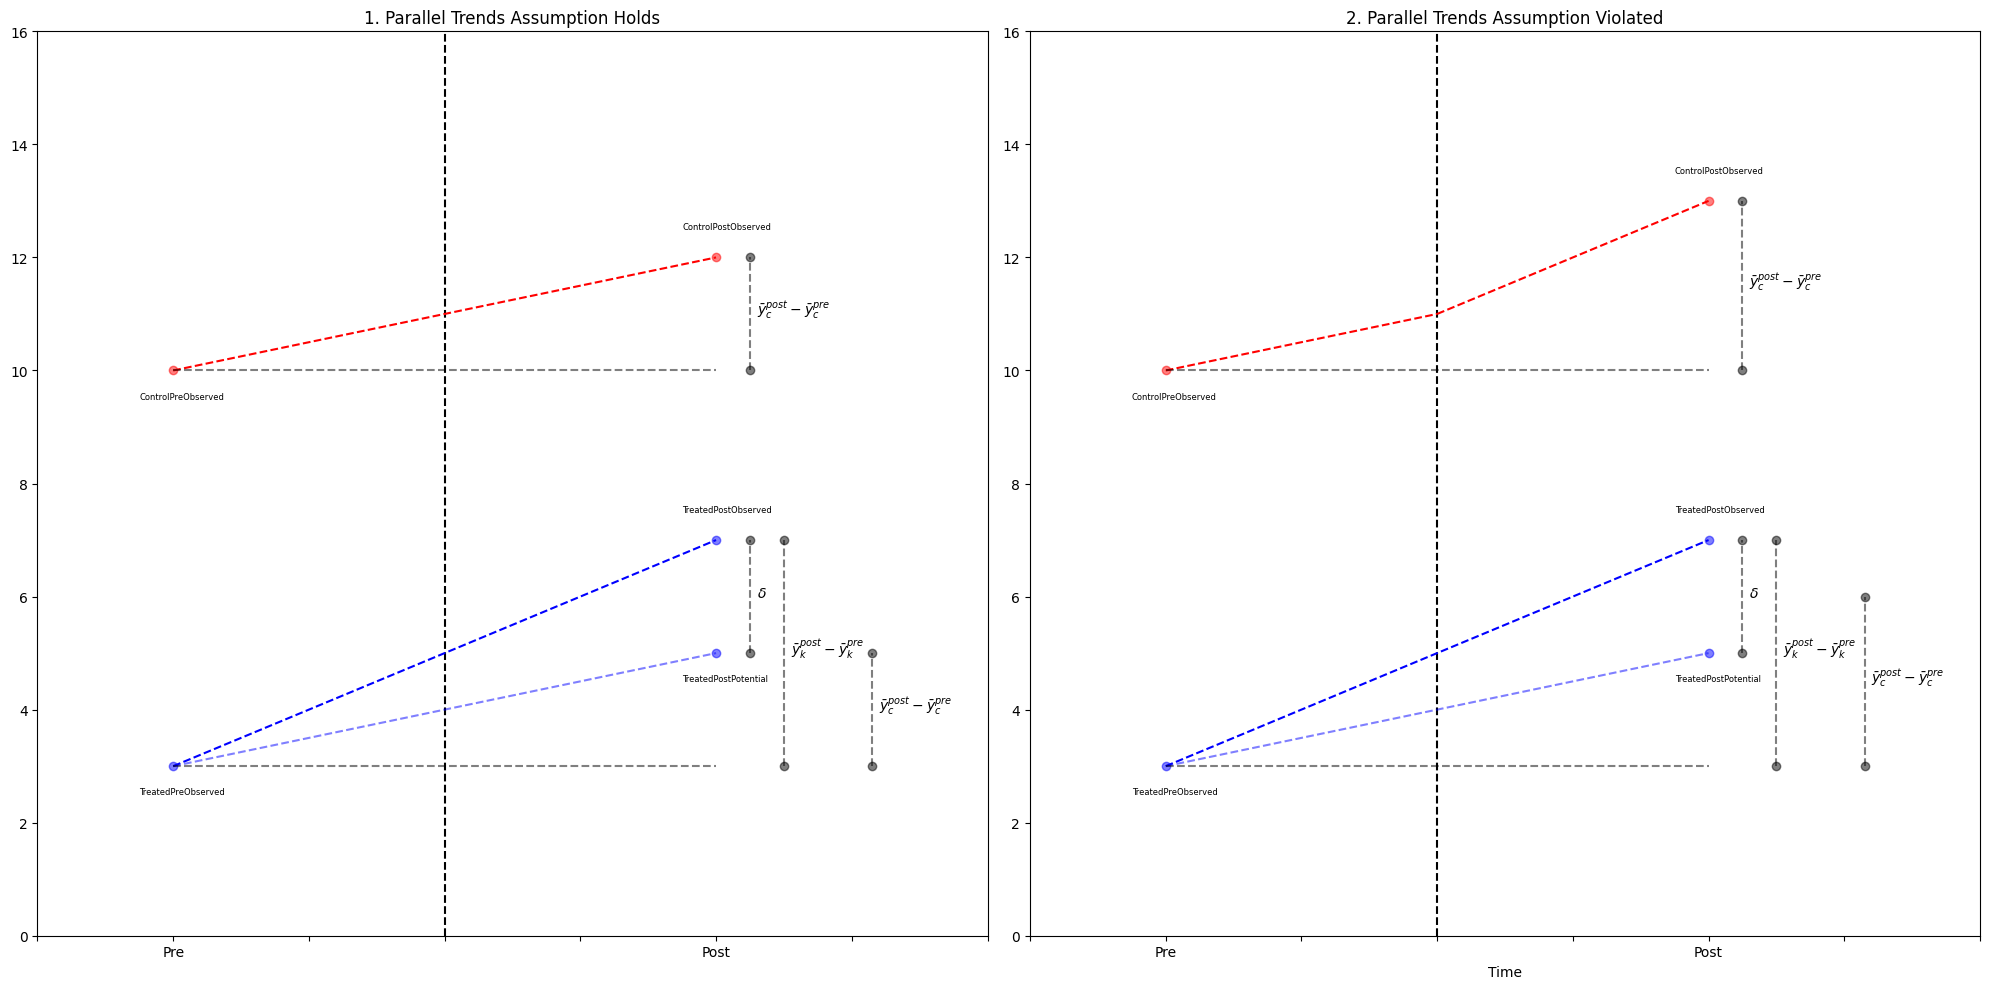

In [204]:
# Here I want to make a plot that I can annotate to graphically illustrate DiD
# I also want to make a plot that shows graphically what happens to our estimate if we violate the parallel trends assumption
pre = 2
post = 10
treatment = 6

treated_pre = 3
control_pre = 10

treated_post_observed = 7
treated_post_potential = 5
control_post_observed = 12
control_post_observed_non_paralell = 13

fig, ax = plt.subplots(1, 2, figsize=(20, 10))
ax[0].set_xlim(0, 14)
ax[0].set_ylim(0, 16)
ax[0].axvline(x=treatment, color='black', linestyle='--', label='Treatment')
ax[0].set_xticklabels(['', 'Pre', '', '', '', 'Post'])
ax[1].set_xlim(0, 14)
ax[1].set_ylim(0, 16)
ax[1].axvline(x=treatment, color='black', linestyle='--', label='Treatment')
ax[1].set_xticklabels(['', 'Pre', '', '', '', 'Post'])
ax[1].set_xlabel('Time')

ax[0].plot(pre, treated_pre, marker='o', alpha=0.5, color='blue')
ax[0].annotate('TreatedPreObserved', xy=(pre, treated_pre), xytext=(pre - 0.5, treated_pre - 0.5), fontsize=6)
ax[0].plot(post, treated_post_observed, marker='o', alpha=0.5, color='blue')
ax[0].annotate('TreatedPostObserved', xy=(post, treated_post_observed), xytext=(post - 0.5, treated_post_observed + 0.5), fontsize=6)
ax[0].plot(post, treated_post_potential, marker='o', alpha=0.5, color='blue')
ax[0].annotate('TreatedPostPotential', xy=(post, treated_post_potential), xytext=(post - 0.5, treated_post_potential - 0.5), fontsize=6)
ax[0].plot([pre, post], [treated_pre, treated_post_observed], color='blue', linestyle='--')
ax[0].plot([pre, post], [treated_pre, treated_post_potential], color='blue', alpha=0.5, linestyle='--')
ax[0].plot(pre, control_pre, marker='o', alpha=0.5, label='ControlPreObserved', color='Red')
ax[0].annotate('ControlPreObserved', xy=(pre, control_pre), xytext=(pre - 0.5, control_pre - 0.5), fontsize=6)
ax[0].plot(post, control_post_observed, marker='o', alpha=0.5, color='Red')
ax[0].annotate('ControlPostObserved', xy=(post, control_post_observed), xytext=(post - 0.5, control_post_observed + 0.5), fontsize=6)
ax[0].plot([pre, post], [control_pre, control_post_observed], color='Red', linestyle='--')

ax[0].plot([post+0.5, post+0.5], [treated_post_potential, treated_post_observed], color='black', marker='o', linestyle='--', alpha=0.5)
ax[0].annotate('$\\delta$', xy=(post+0.5, (treated_post_observed + treated_post_potential) / 2), xytext=(post + 0.6, (treated_post_observed + treated_post_potential) / 2), fontsize=10)

ax[0].plot([pre, post], [control_pre, control_pre], color='black', linestyle='--', alpha=0.5)
ax[0].plot([post+0.5, post+0.5], [control_pre, control_post_observed], color='black', marker='o', linestyle='--', alpha=0.5)
ax[0].annotate('$\\bar{y}_{c}^{post} - \\bar{y}_{c}^{pre}$', xy=(post+0.5, (control_post_observed + control_pre) / 2), xytext=(post + 0.6, (control_post_observed + control_pre) / 2), fontsize=10)

ax[0].plot([pre, post], [treated_pre, treated_pre], color='black', linestyle='--', alpha=0.5)
ax[0].plot([post+1, post+1], [treated_pre, treated_post_observed], color='black', marker='o', linestyle='--', alpha=0.5)
ax[0].annotate('$\\bar{y}_{k}^{post} - \\bar{y}_{k}^{pre}$', xy=(post+1, (treated_post_observed + treated_pre) / 2), xytext=(post + 1.1, (treated_post_observed + treated_pre) / 2), fontsize=10)
ax[0].plot([post+2.3, post+2.3], [treated_pre, treated_post_potential], color='black', marker='o', linestyle='--', alpha=0.5)
ax[0].annotate('$\\bar{y}_{c}^{post} - \\bar{y}_{c}^{pre}$', xy=(post+2.3, (treated_pre + treated_post_potential) / 2), xytext=(post + 2.4, (treated_pre + treated_post_potential) / 2), fontsize=10)

ax[0].set_title('1. Parallel Trends Assumption Holds')


ax[1].plot(pre, treated_pre, marker='o', alpha=0.5, color='blue')
ax[1].annotate('TreatedPreObserved', xy=(pre, treated_pre), xytext=(pre - 0.5, treated_pre - 0.5), fontsize=6)
ax[1].plot(post, treated_post_observed, marker='o', alpha=0.5, color='blue')
ax[1].annotate('TreatedPostObserved', xy=(post, treated_post_observed), xytext=(post - 0.5, treated_post_observed + 0.5), fontsize=6)
ax[1].plot(post, treated_post_potential, marker='o', alpha=0.5, color='blue')
ax[1].annotate('TreatedPostPotential', xy=(post, treated_post_potential), xytext=(post - 0.5, treated_post_potential - 0.5), fontsize=6)
ax[1].plot([pre, post], [treated_pre, treated_post_observed], color='blue', linestyle='--')
ax[1].plot([pre, post], [treated_pre, treated_post_potential], color='blue', alpha=0.5, linestyle='--')
ax[1].plot(pre, control_pre, marker='o', alpha=0.5, label='ControlPreObserved', color='Red')
ax[1].annotate('ControlPreObserved', xy=(pre, control_pre), xytext=(pre - 0.5, control_pre - 0.5), fontsize=6)
ax[1].plot(post, control_post_observed_non_paralell, marker='o', alpha=0.5, color='Red')
ax[1].annotate('ControlPostObserved', xy=(post, control_post_observed_non_paralell), xytext=(post - 0.5, control_post_observed_non_paralell + 0.5), fontsize=6)
ax[1].plot([pre, treatment], [control_pre, (control_pre + control_post_observed)/2], color='Red', linestyle='--')
ax[1].plot([treatment, post], [ (control_pre + control_post_observed)/2, control_post_observed_non_paralell], color='Red', linestyle='--')

ax[1].plot([post+0.5, post+0.5], [treated_post_potential, treated_post_observed], color='black', marker='o', linestyle='--', alpha=0.5)
ax[1].annotate('$\\delta$', xy=(post+0.5, (treated_post_observed + treated_post_potential) / 2), xytext=(post + 0.6, (treated_post_observed + treated_post_potential) / 2), fontsize=10)

ax[1].plot([pre, post], [control_pre, control_pre], color='black', linestyle='--', alpha=0.5)
ax[1].plot([post+0.5, post+0.5], [control_pre, control_post_observed_non_paralell], color='black', marker='o', linestyle='--', alpha=0.5)
ax[1].annotate('$\\bar{y}_{c}^{post} - \\bar{y}_{c}^{pre}$', xy=(post+0.5, (control_post_observed_non_paralell + control_pre) / 2), xytext=(post + 0.6, (control_post_observed_non_paralell + control_pre) / 2), fontsize=10)

ax[1].plot([pre, post], [treated_pre, treated_pre], color='black', linestyle='--', alpha=0.5)
ax[1].plot([post+1, post+1], [treated_pre, treated_post_observed], color='black', marker='o', linestyle='--', alpha=0.5)
ax[1].annotate('$\\bar{y}_{k}^{post} - \\bar{y}_{k}^{pre}$', xy=(post+1, (treated_post_observed + treated_pre) / 2), xytext=(post + 1.1, (treated_post_observed + treated_pre) / 2), fontsize=10)
ax[1].plot([post+2.3, post+2.3], [treated_pre, treated_pre + (control_post_observed_non_paralell - control_pre)], color='black', marker='o', linestyle='--', alpha=0.5)
ax[1].annotate('$\\bar{y}_{c}^{post} - \\bar{y}_{c}^{pre}$', xy=(post+2.3, (treated_pre + (control_post_observed_non_paralell - control_pre)/2)), xytext=(post + 2.4, (treated_pre + (control_post_observed_non_paralell - control_pre) / 2)), fontsize=10)

ax[1].set_title('2. Parallel Trends Assumption Violated')

plt.tight_layout()
plt.show()

Some explantation

## Load Data

The organ_donation data contains data from Kessler and Roth (2014) on organ donation rates by state and quarter. The state of California enacted an active-choice phrasing for their organ donation sign-up questoin in Q32011. The only states included in the data are California and those that can serve as valid controls; see Kessler and Roth (2014).

Below we plot the donation rate for each state by quarter. The donation rate for California is highlighted in blue... ( what do we see )

In [12]:
# Load data
df = organ_donations.load_pandas().data
df['Year'] = df['Quarter'].str[2:].astype(int)
df.head()

,State,Quarter,Rate,Quarter_Num,Year
0,Alaska,Q42010,0.75,1,2010
1,Alaska,Q12011,0.77,2,2011
2,Alaska,Q22011,0.77,3,2011
3,Alaska,Q32011,0.78,4,2011
4,Alaska,Q42011,0.78,5,2011


In [13]:
california = df[df['State'] == 'California']
rest_of_us = df[df['State'] != 'California']

Text(0.5, 1.0, 'Organ Donations by State')

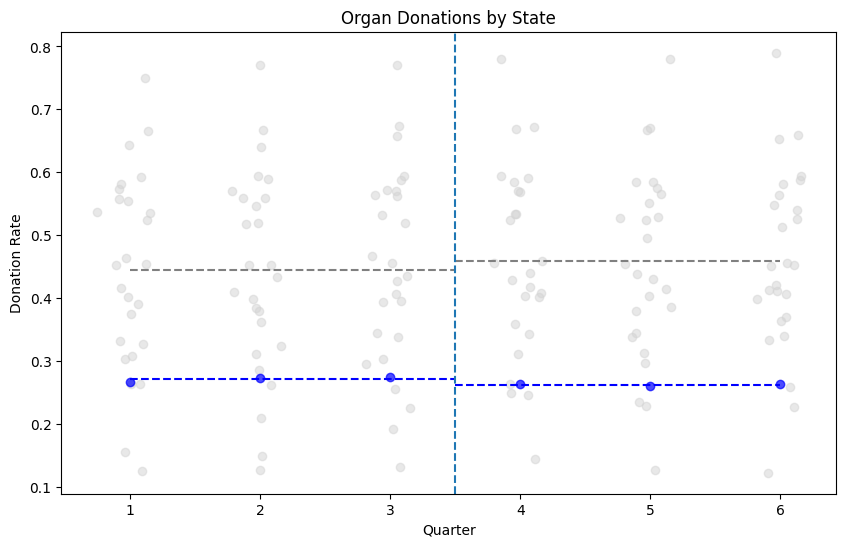

In [27]:
before_treatment_cali_avg = california[california['Quarter_Num'] <= 3]['Rate'].mean()
before_treatment_rest_avg = rest_of_us[rest_of_us['Quarter_Num'] <= 3]['Rate'].mean()
after_treatment_cali_avg = california[california['Quarter_Num'] > 3]['Rate'].mean()
after_treatment_rest_avg = rest_of_us[rest_of_us['Quarter_Num'] > 3]['Rate'].mean()

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(rest_of_us['Quarter_Num'] + np.random.normal(0, 0.1, len(rest_of_us)), rest_of_us['Rate'], color='lightgray', label='Rest of US', alpha=0.5)
ax.scatter(california['Quarter_Num'], california['Rate'], color='blue', label='California', alpha=0.7)

ax.plot([1, 3.5], [before_treatment_rest_avg, before_treatment_rest_avg], color='gray', linestyle='--', label='Rest of US Avg (Before)')
ax.plot([3.5, 6], [after_treatment_rest_avg, after_treatment_rest_avg], color='gray', linestyle='--', label='Rest of US Avg (After)')

ax.plot([1, 3.5], [before_treatment_cali_avg, before_treatment_cali_avg], color='blue', linestyle='--', label='California Avg (Before)')
ax.plot([3.5, 6], [after_treatment_cali_avg, after_treatment_cali_avg], color='blue', linestyle='--', label='California Avg (After)')
ax.axvline(x=3.5, label='Policy Change', linestyle='--')
ax.set_xlabel('Quarter')
ax.set_ylabel('Donation Rate')
ax.set_title('Organ Donations by State')


## Assumptions

In [28]:
# Testing assumptions

## Estimation

Implement the DiD estimator

In [9]:
## Estimation

## Placebo Tests

## Bibliography

Kessler & Roth (2014)